## 基于字符级别RNN的姓名分类

参考：https://github.com/spro/practical-pytorch

任务：输入一个人名，判断改名字是哪个国家的人名，例如：

Jiaxin -> Chinese

Alice -> English

### 名字分类任务数据读取

In [3]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
import torch.nn as nn

# 固定随机数生成器种子，保证每次运行结果一致
np.random.seed(1125)
torch.manual_seed(1125)
torch.cuda.manual_seed(1125)

# 读取数据
def read_data(filename):
    X = list()
    y = list()

    with open(filename, 'r') as fin:
        for line in fin:
            # print(line)
            name, country = line.strip().split(',')
            X.append(name)
            y.append(country)

    # 构造字符到整数的映射
    index2char = sorted(set(''.join(X)))
    char2index = {c: i for i, c in enumerate(index2char)}
    X = np.array(X)

    # 构造country到整数的映射
    index2country = sorted(set(y))
    country2index = {c: i for i, c in enumerate(index2country)}
    y = np.array([[country2index[c]] for c in y])
    
    return X, y, index2char, char2index, index2country, country2index

def split_data(X, y, split_ratio=0.7):
    # 训练测试划分
    data_size = len(X)
    shuffled_index = np.random.permutation(data_size)
    X, y = X[shuffled_index], y[shuffled_index]
    split_index = int(data_size * split_ratio)
    X_train = X[:split_index]
    y_train = y[:split_index]
    X_test = X[split_index:]
    y_test = y[split_index:]
    return X_train, y_train, X_test, y_test

# 绘制混淆矩阵
def plot_confusion_matrix(y_pred, y_true, county2index):
    n_categories = len(country2index)
    confusion = np.zeros((n_categories, n_categories))

    # confusion[i, j]： 将第i类样本预测为第j类样本的次数
    for i in range(len(y_true)):
        confusion[y_true[i][0], y_pred[i][0]] += 1.

    # 按行归一化，归一化后confusion[i, j]为将第i类样本预测为第j类样本的概率
    confusion = confusion / confusion.sum(axis=1).reshape(18, 1)
    
    # 绘制混淆矩阵
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(confusion)
    fig.colorbar(cax)

    ax.set_xticklabels([''] + index2country, rotation=90)
    ax.set_yticklabels([''] + index2country)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()


X, y, index2char, char2index, index2country, country2index = read_data('names_of_different_countries.txt')
X_train, y_train, X_test, y_test = split_data(X, y)

In [4]:


# 定义RNN
class TorchRNN(nn.Module):
    def __init__(self, vocab_size, embedding_size, hidden_size, output_size, model='RNN'):
        super().__init__()
        
        self.hidden_size = hidden_size
        self.embeddings = nn.Embedding(vocab_size, embedding_size)
        
        assert model in ['RNN', 'LSTM', 'GRU'], "Only support RNN/LSTM/GRU model"
        
        if model == 'RNN':
            self.rnn = nn.RNN(embedding_size, hidden_size)
        elif model == 'LSTM':
            self.rnn = nn.LSTM(embedding_size, hidden_size)
        elif model == 'GRU':
            self.rnn = nn.GRU(embedding_size, hidden_size)
        
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, input):
        input_embeddings = self.embeddings(input)
        hidden, _ = self.rnn(input_embeddings)
        output = self.output(hidden)
        return output, hidden

# 定义RNN分类模型
class RNNClassifier():
    def __init__(self, char2index, output_dim, 
                 embedding_dim=128, 
                 hidden_dim=128,
                 model='RNN',
                 batch_size=16):
        """
        创建模型和优化器，初始RNN模型和优化器超参数
        """     
        self.lr = 0.001 * batch_size
        self.epoches = 32
        self.batch_size = batch_size
        
        self.num_chars = len(char2index) # 用于将字符映射到整数的字典，其大小为字典大小
        self.char2index = char2index
        
        self.model = TorchRNN(self.num_chars, embedding_dim, hidden_dim, output_dim, model=model)
        self.optimizer = torch.optim.SGD(self.model.parameters(), lr=self.lr)
        self.loss_function = nn.CrossEntropyLoss()
    
    def train(self, X, y):
        """
        训练模型
        输入:
            X: 训练数据,(N,),每个元素是包含名字信息的字符串
            y: 训练数据的真实分类, (N, 1), 每个元素是名字所属的类别
        返回: 
            epoch_losses: 每个epoch的平均损失函数值
        """
        epoch_losses = []
        data_size = X.shape[0]
        for epoch in range(self.epoches):
            losses = []
            
            # 每轮训练前打乱数据的顺序
            shuffled_index = np.random.permutation(data_size)
            X, y = X[shuffled_index], y[shuffled_index]
            
            for i in tqdm(range(0, data_size, self.batch_size)):
                # x.shape = (length, batch_size)
                x = self.get_batch_tensor(X[i:i+self.batch_size])
                
                # y_true.shape = (batch_size, ), y 是一个{0, 1, ..., 17}范围内的整数组成的向量，代表x属于的分类
                y_true = torch.tensor(y[i:i+self.batch_size], dtype=torch.long)
                # 上一步得到的y_true.shape为(batch_size, 1)，将其转化为(batch_size, )
                y_true = y_true.view(-1)
                
                output, hidden = self.model(x)
                # output[-1].shape = (batch_size, 18)
                loss = self.loss_function(output[-1], y_true)
                
                # 反向传播，更新参数
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
                
                # 记录loss
                losses.append(loss.item() * self.batch_size)
                
            # 计算每个epoch的平均loss并输出
            epoch_losses.append(sum(losses) / data_size)
            print("epoch: {}, avg loss is: {}".format(epoch, epoch_losses[-1]))
        
        return epoch_losses
    
    def test(self, X, y):
        """
        用训练好的模型在测试集上进行测试
        输入:
            X: 测试数据,(N,),每个元素是包含名字信息的字符串
            y: 测试数据的真实分类, (N, 1), 每个元素是名字所属的类别
        返回:
            y_pred: 测试数据的预测分类结果
            accuracy: 分类准确率
        """
        data_size = X.shape[0]
        y_pred = torch.empty(y.shape).long() # 预测分类与真实分类的形状相同
        for i in range(data_size):
            x = torch.tensor([[self.char2index[c]] for c in X[i]], dtype=torch.long)
            
            output, hidden = self.model(x)
            # output.shape = (1, 18)
            top_n, top_i = output[-1].topk(1)
            y_pred[i] = top_i[0]
        
        # 将y转化为tensor,并计算accuracy
        accuracy = self.accuracy(torch.from_numpy(y), y_pred)
        
        return y_pred, accuracy
    
    def get_batch_tensor(self, X):
        batch_size = len(X)
        max_len = max(map(len, X))
        ret_tensor = torch.zeros(max_len, batch_size, dtype=torch.long)
        for i in range(batch_size):
            x = torch.tensor([[self.char2index[c]] for c in X[i]], dtype=torch.long)
            ret_tensor[-len(X[i]):, i:i+1] = x
        return ret_tensor
    
    def accuracy(self, y_true, y_pred):
        return torch.where(y_true == y_pred, 1.0, 0.0).mean().item()
            

  3%|▎         | 22/879 [00:00<00:04, 211.53it/s]

epoch: 0, avg loss is: 1.261412847204129


  2%|▏         | 16/879 [00:00<00:05, 150.93it/s]

epoch: 1, avg loss is: 0.9649348483120587


  2%|▏         | 16/879 [00:00<00:05, 156.85it/s]

...

  3%|▎         | 22/879 [00:00<00:03, 217.81it/s]

epoch: 30, avg loss is: 0.25382188403278083


100%|██████████| 879/879 [00:04<00:00, 187.33it/s]


epoch: 31, avg loss is: 0.24416854280855688
Accuracy on training set: 0.875169038772583


<ipython-input-3-14a1a6f56d9b>:67: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([''] + index2country, rotation=90)
<ipython-input-3-14a1a6f56d9b>:68: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([''] + index2country)


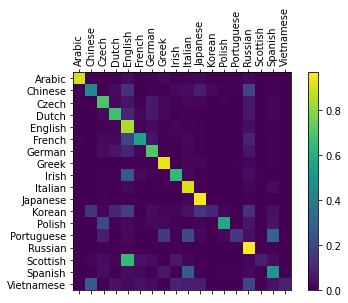

Accuracy on test set: 0.7869832515716553


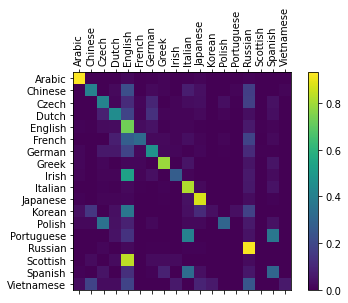

In [6]:
classifier = RNNClassifier(char2index, len(country2index), model='RNN')
rnn_losses = classifier.train(X_train, y_train)

# 在训练集上进行测试
y_pred, accuracy = classifier.test(X_train, y_train)
print("Accuracy on training set: {}".format(accuracy))

# 绘制混淆矩阵
plot_confusion_matrix(y_pred, y_train, country2index)

# 在测试集上进行测试
y_pred, accuracy = classifier.test(X_test, y_test)
print("Accuracy on test set: {}".format(accuracy))

# 绘制混淆矩阵
plot_confusion_matrix(y_pred, y_test, country2index)

In [ ]:
classifier = RNNClassifier(char2index, len(country2index), model='LSTM')
lstm_losses = classifier.train(X_train, y_train)

# 在训练集上进行测试
y_pred, accuracy = classifier.test(X_train, y_train)
print("Accuracy on training set: {}".format(accuracy))

# 绘制混淆矩阵
plot_confusion_matrix(y_pred, y_train, country2index)

# 在测试集上进行测试
y_pred, accuracy = classifier.test(X_test, y_test)
print("Accuracy on test set: {}".format(accuracy))

# 绘制混淆矩阵
plot_confusion_matrix(y_pred, y_test, country2index)

  3%|▎         | 30/879 [00:00<00:02, 295.35it/s]

epoch: 0, avg loss is: 1.4249373625948814


  4%|▎         | 31/879 [00:00<00:02, 303.67it/s]

epoch: 1, avg loss is: 1.1372755969786472


  4%|▎         | 31/879 [00:00<00:02, 306.71it/s]

...

  3%|▎         | 30/879 [00:00<00:02, 296.59it/s]

epoch: 30, avg loss is: 0.3639516000500774


100%|██████████| 879/879 [00:02<00:00, 296.68it/s]


epoch: 31, avg loss is: 0.3565054376459231
Accuracy on training set: 0.8062059879302979


<ipython-input-1-14a1a6f56d9b>:67: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([''] + index2country, rotation=90)
<ipython-input-1-14a1a6f56d9b>:68: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([''] + index2country)


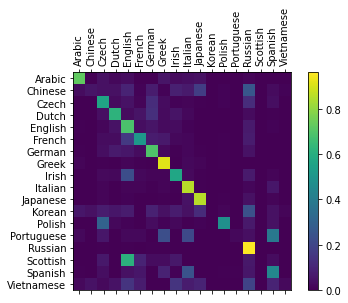

Accuracy on test set: 0.7524489164352417


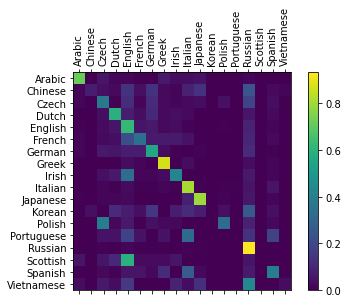

In [5]:
classifier = RNNClassifier(char2index, len(country2index), model='GRU')
gru_losses = classifier.train(X_train, y_train)

# 在训练集上进行测试
y_pred, accuracy = classifier.test(X_train, y_train)
print("Accuracy on training set: {}".format(accuracy))

# 绘制混淆矩阵
plot_confusion_matrix(y_pred, y_train, country2index)

# 在测试集上进行测试
y_pred, accuracy = classifier.test(X_test, y_test)
print("Accuracy on test set: {}".format(accuracy))

# 绘制混淆矩阵
plot_confusion_matrix(y_pred, y_test, country2index)

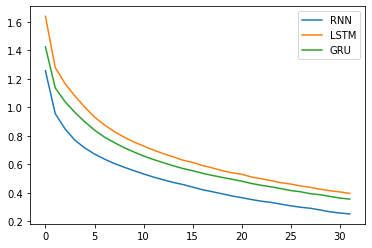

In [6]:
# 绘制三种RNN变种损失函数变化曲线

plt.figure()
plt.plot(rnn_losses, label='RNN')
plt.plot(lstm_losses, label='LSTM')
plt.plot(gru_losses, label='GRU')
plt.legend()
plt.show()